In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import sys

working_directory = Path.cwd().resolve()
project_root = next(
    (path for path in (working_directory, *working_directory.parents)
     if (path / "pyproject.toml").is_file() and (path / "src").is_dir()),
    None,
)
if project_root is None:
    raise RuntimeError("Open this notebook from within the project directory.")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [3]:
from src.data.loader import load_dataset

dataset = load_dataset('ETTh1')
dataset.values.head()

,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
0,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
1,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
3,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
4,5.358,1.942,1.492,0.462,3.868,1.279,21.948000


In [4]:
dataset.values.describe()

,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
count,17420.000000,17420.000000,17420.000000,17420.000000,17420.000000,17420.000000,17420.000000
mean,7.375141,2.242242,4.300239,0.881568,3.066062,0.856932,13.324672
std,7.067744,2.042342,6.826978,1.809293,1.164506,0.599552,8.566946
min,-22.705999,-4.756000,-25.087999,-5.934000,-1.188000,-1.371000,-4.080000
25%,5.827000,0.737000,3.296000,-0.284000,2.315000,0.670000,6.964000
50%,8.774000,2.210000,5.970000,0.959000,2.833000,0.975000,11.396000
75%,11.788000,3.684000,8.635000,2.203000,3.625000,1.218000,18.079000
max,23.643999,10.114000,17.341000,7.747000,8.498000,3.046000,46.007000


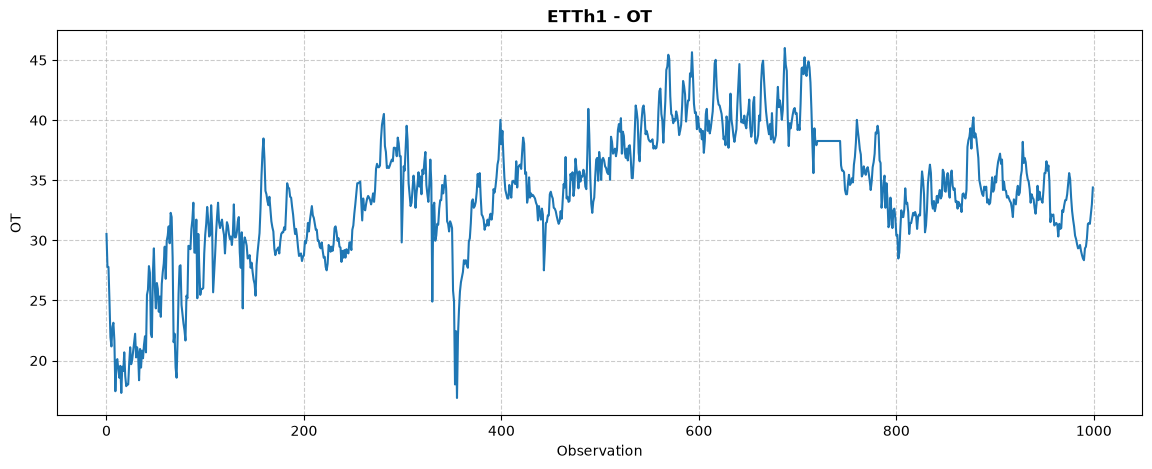

In [6]:
import matplotlib.pyplot as plt

dataset.values['OT'].iloc[:1000].plot(figsize=(14, 5))

plt.title("ETTh1 - OT", fontweight='bold')
plt.xlabel('Observation')
plt.ylabel('OT')
plt.grid(True, alpha=0.65, linestyle='--')

plt.show()

In [7]:
dataset.timestamps[:10]

DatetimeIndex(['2016-07-01 00:00:00', '2016-07-01 01:00:00',
               '2016-07-01 02:00:00', '2016-07-01 03:00:00',
               '2016-07-01 04:00:00', '2016-07-01 05:00:00',
               '2016-07-01 06:00:00', '2016-07-01 07:00:00',
               '2016-07-01 08:00:00', '2016-07-01 09:00:00'],
              dtype='datetime64[us]', name='date', freq=None)

In [8]:
dataset.timestamps.to_series().diff().value_counts().head()

date
0 days 01:00:00    17419
Name: count, dtype: int64

In [9]:
context = 512
horizon = 192

required_length = context + horizon

print("Available:", dataset.n_observations)
print("Required:", required_length)
print(f"Valid: {dataset.n_observations >= required_length}")

Available: 17420
Required: 704
Valid: True
